<a href="https://colab.research.google.com/github/emortalizer/Colab-Assignment-6_1/blob/main/Assignment_six.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`
california_housing = fetch_california_housing()

# Create DataFrame with feature names
df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)

# Add the target variable (Median House Value in $100,000s)
df['MedHouseVal'] = california_housing.target

In [4]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
print("First 5 rows of the dataset:")
display(df.head())   # or print(df.head())

# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      

In [5]:
#All features and the target are **continuous** (regression problem). No categorical variables.

# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


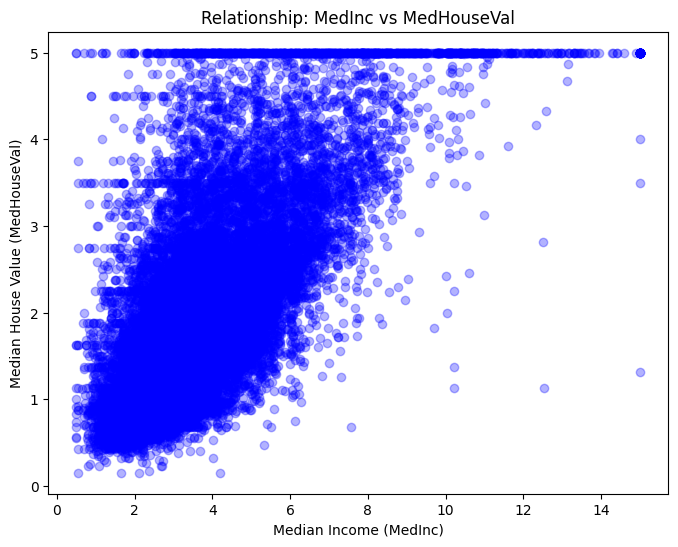

In [6]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example for one feature:
plt.figure(figsize=(8, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, color='blue')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Relationship: MedInc vs MedHouseVal')
plt.show()

In [8]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
def plot_scatter_vs_target(features, target_col, data):
    """
    Creates scatter plots for a list of features against the target variable.
    """
    for feature in features:
        plt.figure(figsize=(8, 6))
        plt.scatter(data[feature], data[target_col], alpha=0.3, color='blue')
        plt.xlabel(feature)
        plt.ylabel(target_col)
        plt.title(f'{feature} vs {target_col}')
        plt.show()

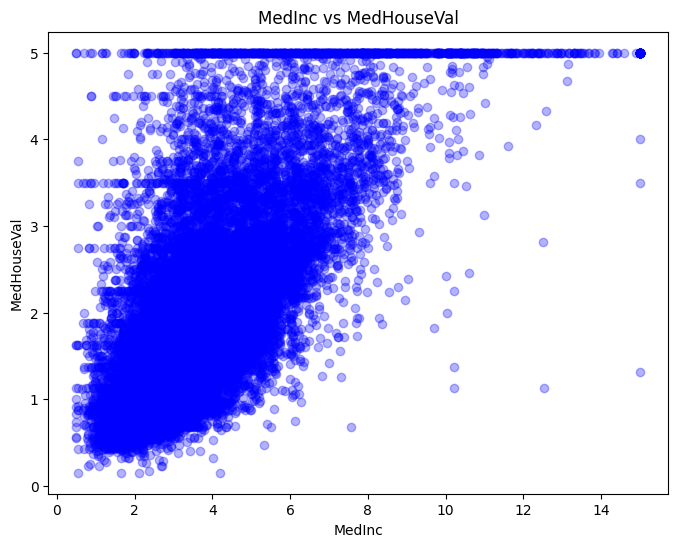

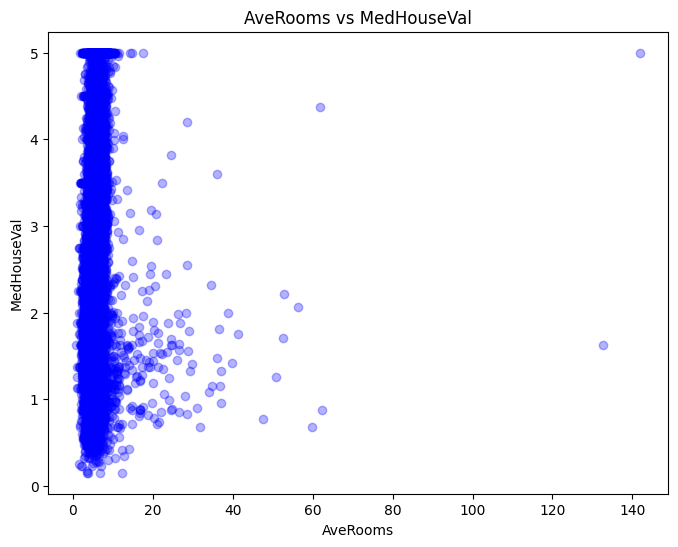

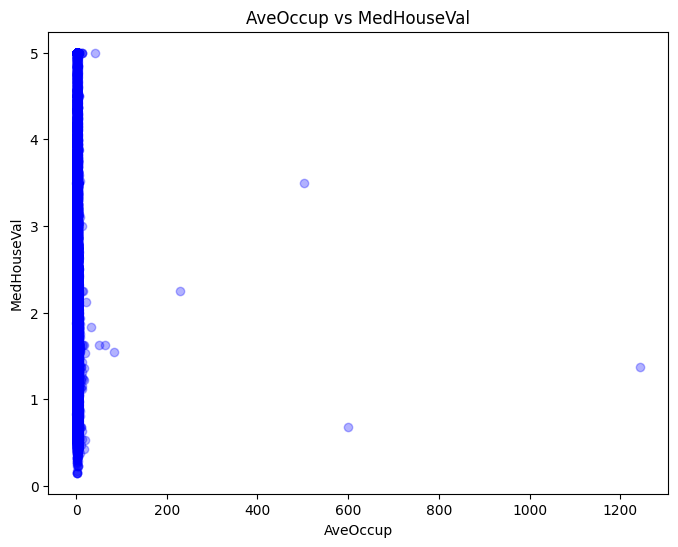

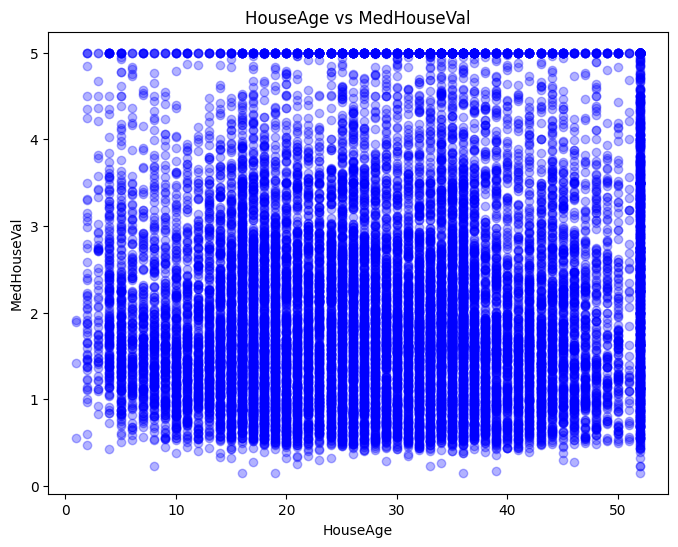

In [9]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
selected_features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
plot_scatter_vs_target(selected_features, 'MedHouseVal', df)

In [10]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
X = df.drop('MedHouseVal', axis=1)   # All features
y = df['MedHouseVal']                # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 16512
Test set size: 4128


In [11]:
# TODO: Choosen an appropriate regression model.
model = LinearRegression()

# TODO: Train the model on the training data.
model.fit(X_train, y_train)

print("Model training completed.")

# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Model training completed.

Model Evaluation on Test Set:
Root Mean Squared Error (RMSE): 0.7456
R-squared (R²): 0.5758


In [12]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Feature order must match the training data:
# ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude', 'AveBedrms', 'Population']

new_data = np.array([[
    3.0,      # MedInc
    30.0,     # HouseAge
    6.0,      # AveRooms
    3.0,      # AveOccup
    34.0,     # Latitude
    -118.0,   # Longitude
    1.0,      # AveBedrms
    1500.0    # Population
]])

predicted_value = model.predict(new_data)[0]

print(f"\nPredicted Median House Value for new data: ${predicted_value*100_000:,.2f}")


Predicted Median House Value for new data: $-68,434,188.39


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
